In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("/content/email_dataset_160.csv")

In [3]:
df.head()

,text,category
0,You have been selected for a prize,Spam
1,Biggest sale of the year,Promotion
2,John liked your photo,Social
3,Your interview is scheduled for tomorrow,Important
4,You have been selected for a prize,Spam


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 160 entries, 0 to 159
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   text      160 non-null    object
 1   category  160 non-null    object
dtypes: object(2)
memory usage: 2.6+ KB


In [5]:
df.isnull().sum()

,0
text,0
category,0


In [6]:
import re
import nltk
import joblib

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [7]:
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


True

In [9]:
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def preprocess(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    words = text.split()
    words = [lemmatizer.lemmatize(word) for word in words if word not in stop_words]
    return " ".join(words)

df['clean_text'] = df['text'].apply(preprocess)

vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(df['clean_text'])
y = df['category']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,random_state=42)


model = LogisticRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)


print("Accuracy : ", accuracy_score(y_test, y_pred))
print("\nClasification Report : ",classification_report(y_test, y_pred))
print("\nConfusion Matrix : ", confusion_matrix(y_test, y_pred))

joblib.dump(model, "model.pkl")
joblib.dump(vectorizer, "vectorizer.pkl")

print("Model Saved")


Accuracy :  1.0

Clasification Report :                precision    recall  f1-score   support

   Important       1.00      1.00      1.00         9
   Promotion       1.00      1.00      1.00         6
      Social       1.00      1.00      1.00         7
        Spam       1.00      1.00      1.00        10

    accuracy                           1.00        32
   macro avg       1.00      1.00      1.00        32
weighted avg       1.00      1.00      1.00        32


Confusion Matrix :  [[ 9  0  0  0]
 [ 0  6  0  0]
 [ 0  0  7  0]
 [ 0  0  0 10]]
Model Saved


<Axes: >

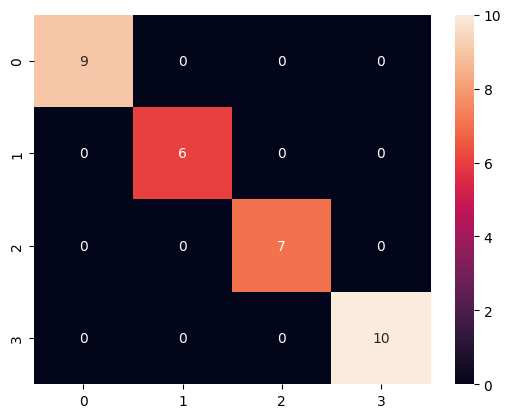

In [10]:
import seaborn as sns

sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='g')